Import the required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


Load your CSV

In [3]:
import pandas as pd

# File location
file_path = r"C:\Users\10689473\Downloads\college_sleep_and_gpa.csv"

# Load dataset
df = pd.read_csv(file_path)

# Display basic information
print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display first 5 rows
display(df.head())

Dataset loaded successfully!
Number of rows: 634
Number of columns: 22


,student_id,study,university,semester,cohort_code,gender,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,...,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep,sleep_bracket,sleep_midpoint_clock
0,293,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,370.0,6.17,...,0.0500,0.931,4.00,3.76,-0.24,49.0,0.112,0,6-6.5h,07:20
1,294,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,406.8,6.78,...,0.0476,0.862,4.00,3.55,-0.45,49.0,0.112,0,6.5-7h,05:00
2,297,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,253.8,4.23,...,0.1639,0.586,3.00,3.59,0.59,46.0,-0.604,1,<5.5h,05:38
3,303,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,411.9,6.86,...,0.7854,0.931,3.80,3.46,-0.34,39.0,-2.275,0,6.5-7h,07:52
4,304,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,408.1,6.80,...,0.1538,0.931,3.17,3.50,0.33,39.0,-2.275,0,6.5-7h,04:54


Data Types

In [4]:
print(df.dtypes)

student_id                   int64
study                        int64
university                     str
semester                       str
cohort_code                    str
gender                         str
first_generation           float64
underrepresented           float64
avg_sleep_minutes          float64
avg_sleep_hours            float64
daytime_sleep_minutes      float64
sleep_midpoint_minutes     float64
bedtime_variability        float64
nights_tracked_fraction    float64
prior_gpa                  float64
term_gpa                   float64
gpa_change                 float64
term_units                 float64
term_load_z                float64
under_6h_sleep               int64
sleep_bracket                  str
sleep_midpoint_clock           str
dtype: object


Complete Dataset Summary

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               634 non-null    int64  
 1   study                    634 non-null    int64  
 2   university               634 non-null    str    
 3   semester                 634 non-null    str    
 4   cohort_code              634 non-null    str    
 5   gender                   631 non-null    str    
 6   first_generation         630 non-null    float64
 7   underrepresented         633 non-null    float64
 8   avg_sleep_minutes        634 non-null    float64
 9   avg_sleep_hours          634 non-null    float64
 10  daytime_sleep_minutes    634 non-null    float64
 11  sleep_midpoint_minutes   634 non-null    float64
 12  bedtime_variability      634 non-null    float64
 13  nights_tracked_fraction  634 non-null    float64
 14  prior_gpa                634 non-null

Check missing values

In [6]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
student_id                   0
study                        0
university                   0
semester                     0
cohort_code                  0
gender                       3
first_generation             4
underrepresented             1
avg_sleep_minutes            0
avg_sleep_hours              0
daytime_sleep_minutes        0
sleep_midpoint_minutes       0
bedtime_variability          0
nights_tracked_fraction      0
prior_gpa                    0
term_gpa                     0
gpa_change                   0
term_units                 147
term_load_z                147
under_6h_sleep               0
sleep_bracket                0
sleep_midpoint_clock         0
dtype: int64


Check duplicate records

In [8]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

duplicate_student_ids = df["student_id"].duplicated().sum()

print("Duplicate student IDs:", duplicate_student_ids)

Number of duplicate rows: 0
Duplicate student IDs: 87


Identify the target variable

In [10]:
target = "under_6h_sleep"
print("Target variable:", target)
print("\nTarget values:")
print(df[target].value_counts())

Target variable: under_6h_sleep

Target values:
under_6h_sleep
0    502
1    132
Name: count, dtype: int64


*The meaning is:*
*0 → Student is not under 6 hours of sleep*
*1 → Student is under 6 hours of sleep*
*Therefore, this is a:*
*Binary classification problem*

Visualize the Target Distribution

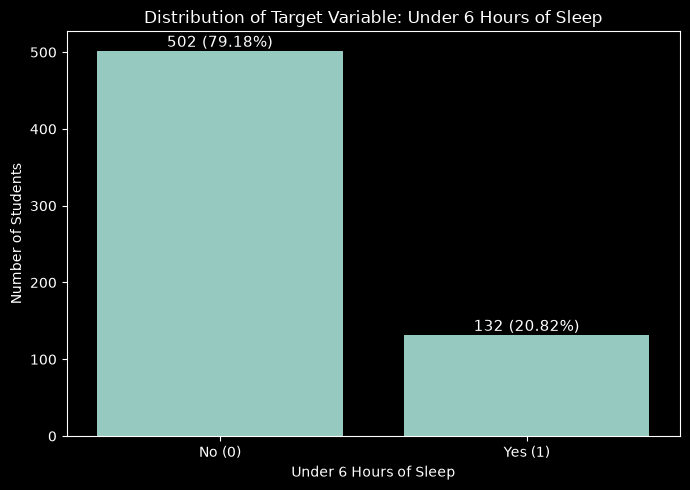

Target Variable Distribution:
under_6h_sleep
0    502
1    132
Name: count, dtype: int64

Target Variable Percentage:
under_6h_sleep
0    79.18
1    20.82
Name: proportion, dtype: float64


In [11]:
# 1.12 Visualize the Target Distribution

import matplotlib.pyplot as plt
import seaborn as sns

# Count the target classes
target_counts = df["under_6h_sleep"].value_counts().sort_index()

# Calculate percentages
target_percentages = df["under_6h_sleep"].value_counts(normalize=True).sort_index() * 100

# Create the plot
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="under_6h_sleep"
)

# Add count and percentage labels on top of each bar
for i, count in enumerate(target_counts):
    percentage = target_percentages.iloc[i]
    ax.text(
        i,
        count + 5,
        f"{count} ({percentage:.2f}%)",
        ha="center",
        fontsize=11
    )

# Customize the plot
plt.title("Distribution of Target Variable: Under 6 Hours of Sleep")
plt.xlabel("Under 6 Hours of Sleep")
plt.ylabel("Number of Students")
plt.xticks([0, 1], ["No (0)", "Yes (1)"])

plt.tight_layout()
plt.show()

# Print the distribution
print("Target Variable Distribution:")
print(target_counts)

print("\nTarget Variable Percentage:")
print(target_percentages.round(2))

Numerical feature summary

In [12]:
numerical_columns = df.select_dtypes(include=np.number).columns

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
student_id,634.0,13005.892744,26496.593477,1.0000,178.00000,358.500,592.75000,99978.0000
study,634.0,3.181388,1.317125,1.0000,2.00000,3.000,4.00000,5.0000
first_generation,630.0,0.166667,0.377213,0.0000,0.00000,0.000,0.00000,2.0000
underrepresented,633.0,0.187994,0.391016,0.0000,0.00000,0.000,0.00000,1.0000
avg_sleep_minutes,634.0,397.324763,50.855641,194.8000,366.95000,400.350,430.10000,587.7000
avg_sleep_hours,634.0,6.622098,0.847741,3.2500,6.11250,6.675,7.17000,9.7900
daytime_sleep_minutes,634.0,41.165615,27.388294,2.3000,23.10000,35.000,51.25000,292.3000
sleep_midpoint_minutes,634.0,398.678707,72.712017,247.1000,345.17500,388.250,437.62500,724.7000
bedtime_variability,634.0,0.451687,1.393631,0.0045,0.07470,0.135,0.29170,20.8492
nights_tracked_fraction,634.0,0.867478,0.178999,0.2140,0.82100,0.932,1.00000,1.0000


Categorical feature summary

In [13]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(list(categorical_columns))
for column in categorical_columns:
    print("\n" + "=" * 50)
    print(column)
    print(df[column].value_counts(dropna=False))

Categorical columns:
['university', 'semester', 'cohort_code', 'gender', 'sleep_bracket', 'sleep_midpoint_clock']

university
university
University of Washington      279
Carnegie Mellon University    208
University of Notre Dame      147
Name: count, dtype: int64

semester
semester
Spring 2018    217
Spring 2016    147
Spring 2019    139
Spring 2017    131
Name: count, dtype: int64

cohort_code
cohort_code
nh      147
uw1     140
uw2     139
lac1    131
lac2     77
Name: count, dtype: int64

gender
gender
Female    368
Male      263
NaN         3
Name: count, dtype: int64

sleep_bracket
sleep_bracket
6.5-7h    172
7-7.5h    126
6-6.5h    123
7.5h+      81
5.5-6h     76
<5.5h      56
Name: count, dtype: int64

sleep_midpoint_clock
sleep_midpoint_clock
05:48    9
05:09    9
04:22    9
06:05    8
04:27    8
        ..
08:12    1
06:42    1
07:40    1
08:53    1
04:13    1
Name: count, Length: 238, dtype: int64


Check the relationship between sleep and target

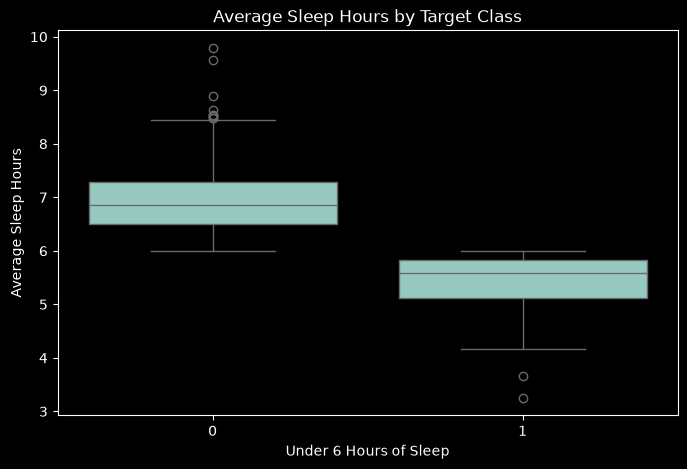

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="under_6h_sleep",
    y="avg_sleep_hours"
)

plt.title("Average Sleep Hours by Target Class")
plt.xlabel("Under 6 Hours of Sleep")
plt.ylabel("Average Sleep Hours")

plt.show()

Create X and y

In [15]:
target = "under_6h_sleep"

drop_columns = [
    "student_id",
    "sleep_bracket",
    "sleep_midpoint_clock",
    target
]

X = df.drop(columns=drop_columns)
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (634, 18)
Target shape: (634,)


Separate numerical and categorical features

In [16]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['study', 'first_generation', 'underrepresented', 'avg_sleep_minutes', 'avg_sleep_hours', 'daytime_sleep_minutes', 'sleep_midpoint_minutes', 'bedtime_variability', 'nights_tracked_fraction', 'prior_gpa', 'term_gpa', 'gpa_change', 'term_units', 'term_load_z']

Categorical features:
['university', 'semester', 'cohort_code', 'gender']


Data Preprocessing and Preparation

In [25]:
# ============================================================
# STEP 2 - DATA PREPROCESSING AND PREPARATION
# ============================================================

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# ------------------------------------------------------------
# 1. Define target
# ------------------------------------------------------------

target = "under_6h_sleep"

print("=" * 60)
print("STEP 2 - DATA PREPROCESSING")
print("=" * 60)

print("\nTarget variable:", target)


# ------------------------------------------------------------
# 2. Remove ID and leakage-prone columns
# ------------------------------------------------------------

columns_to_drop = [
    "student_id",
    "sleep_bracket",
    "sleep_midpoint_clock"
]

df_model = df.drop(columns=columns_to_drop)

print("\nRemoved columns:")
for column in columns_to_drop:
    print("-", column)


# ------------------------------------------------------------
# 3. Separate features and target
# ------------------------------------------------------------

X = df_model.drop(columns=[target])
y = df_model[target]

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)


# ------------------------------------------------------------
# 4. Identify numerical and categorical features
# ------------------------------------------------------------

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)


# ------------------------------------------------------------
# 5. Check missing values
# ------------------------------------------------------------

missing_values = X.isnull().sum()

print("\nMissing values before preprocessing:")
print(missing_values[missing_values > 0])


# ------------------------------------------------------------
# 6. Create numerical preprocessing pipeline
# ------------------------------------------------------------

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


# ------------------------------------------------------------
# 7. Create categorical preprocessing pipeline
# ------------------------------------------------------------

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)


# ------------------------------------------------------------
# 8. Combine preprocessing pipelines
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)


# ------------------------------------------------------------
# 9. Train-test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data shape:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data shape:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


# ------------------------------------------------------------
# 10. Check class distribution
# ------------------------------------------------------------

print("\nTraining target distribution (%):")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting target distribution (%):")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# ------------------------------------------------------------
# 11. Fit preprocessing on training data
# ------------------------------------------------------------

X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)


# ------------------------------------------------------------
# 12. Check processed data
# ------------------------------------------------------------

print("\nProcessed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

print("\nMissing values after preprocessing:")
print("Training:", np.isnan(X_train_processed).sum())
print("Testing :", np.isnan(X_test_processed).sum())


# ------------------------------------------------------------
# 13. Create test_data.csv
# ------------------------------------------------------------

test_data = X_test.copy()
test_data[target] = y_test

test_data.to_csv("test_data.csv", index=False)

print("\ntest_data.csv created successfully.")


# ------------------------------------------------------------
# 14. Save preprocessing pipeline
# ------------------------------------------------------------

joblib.dump(preprocessor, "preprocessor.pkl")

print("preprocessor.pkl saved successfully.")


# ------------------------------------------------------------
# 15. Final summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STEP 2 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Original dataset shape :", df.shape)
print("Feature matrix shape   :", X.shape)
print("Training data shape    :", X_train.shape)
print("Testing data shape     :", X_test.shape)
print("Processed train shape  :", X_train_processed.shape)
print("Processed test shape   :", X_test_processed.shape)

print("\nFiles created:")
print("- test_data.csv")
print("- preprocessor.pkl")

STEP 2 - DATA PREPROCESSING

Target variable: under_6h_sleep

Removed columns:
- student_id
- sleep_bracket
- sleep_midpoint_clock

Feature matrix shape: (634, 18)
Target shape: (634,)

Numerical features:
['study', 'first_generation', 'underrepresented', 'avg_sleep_minutes', 'avg_sleep_hours', 'daytime_sleep_minutes', 'sleep_midpoint_minutes', 'bedtime_variability', 'nights_tracked_fraction', 'prior_gpa', 'term_gpa', 'gpa_change', 'term_units', 'term_load_z']

Categorical features:
['university', 'semester', 'cohort_code', 'gender']

Missing values before preprocessing:
gender                3
first_generation      4
underrepresented      1
term_units          147
term_load_z         147
dtype: int64

Training data shape:
X_train: (507, 18)
y_train: (507,)

Testing data shape:
X_test: (127, 18)
y_test: (127,)

Training target distribution (%):
under_6h_sleep
0    79.09
1    20.91
Name: proportion, dtype: float64

Testing target distribution (%):
under_6h_sleep
0    79.53
1    20.47
Na

Classification Model Implementation

In [26]:
# ============================================================
# STEP 3 - CLASSIFICATION MODEL IMPLEMENTATION
# ============================================================

import os
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline


print("=" * 60)
print("STEP 3 - CLASSIFICATION MODEL IMPLEMENTATION")
print("=" * 60)


# ------------------------------------------------------------
# 1. Create Logistic Regression model
# ------------------------------------------------------------

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)


# ------------------------------------------------------------
# 2. Create Decision Tree model
# ------------------------------------------------------------

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=5,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)


# ------------------------------------------------------------
# 3. Create KNN model
# ------------------------------------------------------------

knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            KNeighborsClassifier(
                n_neighbors=7
            )
        )
    ]
)


# ------------------------------------------------------------
# 4. Create Gaussian Naive Bayes model
# ------------------------------------------------------------

naive_bayes_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            GaussianNB()
        )
    ]
)


# ------------------------------------------------------------
# 5. Create Random Forest model
# ------------------------------------------------------------

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


# ------------------------------------------------------------
# 6. Store all models
# ------------------------------------------------------------

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "KNN": knn_model,
    "Naive Bayes": naive_bayes_model,
    "Random Forest": random_forest_model
}


# ------------------------------------------------------------
# 7. Train all models
# ------------------------------------------------------------

print("\nTraining models...\n")

for model_name, model in models.items():

    model.fit(X_train, y_train)

    print(f"{model_name:<25} trained successfully.")


# ------------------------------------------------------------
# 8. Verify predictions
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PREDICTION CHECK")
print("=" * 60)

for model_name, model in models.items():

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    print(
        f"{model_name:<25} "
        f"Predictions: {len(predictions):<5} "
        f"Probabilities: {len(probabilities)}"
    )


# ------------------------------------------------------------
# 9. Create model directory
# ------------------------------------------------------------

os.makedirs("models", exist_ok=True)


# ------------------------------------------------------------
# 10. Save models
# ------------------------------------------------------------

model_file_names = {
    "Logistic Regression": "models/logistic_regression.pkl",
    "Decision Tree": "models/decision_tree.pkl",
    "KNN": "models/knn.pkl",
    "Naive Bayes": "models/naive_bayes.pkl",
    "Random Forest": "models/random_forest.pkl"
}

for model_name, file_path in model_file_names.items():

    joblib.dump(
        models[model_name],
        file_path
    )

    print(f"Saved: {file_path}")


# ------------------------------------------------------------
# 11. Final status
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STEP 3 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("\nModels implemented:")
for model_name in models:
    print("✓", model_name)

print("\nSaved model files:")
for file_path in model_file_names.values():
    print("✓", file_path)

STEP 3 - CLASSIFICATION MODEL IMPLEMENTATION

Training models...

Logistic Regression       trained successfully.
Decision Tree             trained successfully.
KNN                       trained successfully.
Naive Bayes               trained successfully.
Random Forest             trained successfully.

PREDICTION CHECK
Logistic Regression       Predictions: 127   Probabilities: 127
Decision Tree             Predictions: 127   Probabilities: 127
KNN                       Predictions: 127   Probabilities: 127
Naive Bayes               Predictions: 127   Probabilities: 127
Random Forest             Predictions: 127   Probabilities: 127
Saved: models/logistic_regression.pkl
Saved: models/decision_tree.pkl
Saved: models/knn.pkl
Saved: models/naive_bayes.pkl
Saved: models/random_forest.pkl

STEP 3 COMPLETED SUCCESSFULLY

Models implemented:
✓ Logistic Regression
✓ Decision Tree
✓ KNN
✓ Naive Bayes
✓ Random Forest

Saved model files:
✓ models/logistic_regression.pkl
✓ models/decision_tree.

Model Evaluation

STEP 4 - MODEL EVALUATION

MODEL PERFORMANCE COMPARISON


,Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.9921,1.0000,0.9630,1.0000,0.9811,0.9764
1,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,KNN,0.8819,0.9473,0.9231,0.4615,0.6154,0.6012
3,Naive Bayes,0.9449,0.9874,0.8519,0.8846,0.8679,0.8334
4,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000



BEST MODEL FOR EACH METRIC
Accuracy     → Decision Tree          (1.0000)
AUC          → Logistic Regression    (1.0000)
Precision    → Decision Tree          (1.0000)
Recall       → Logistic Regression    (1.0000)
F1 Score     → Decision Tree          (1.0000)
MCC          → Decision Tree          (1.0000)

MODEL RANKING


,Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC,Average Score
1,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
0,Logistic Regression,0.9921,1.0000,0.9630,1.0000,0.9811,0.9764,0.9854
3,Naive Bayes,0.9449,0.9874,0.8519,0.8846,0.8679,0.8334,0.8950
2,KNN,0.8819,0.9473,0.9231,0.4615,0.6154,0.6012,0.7384



CLASSIFICATION REPORTS

----------------------------------------------------------------------
Logistic Regression
----------------------------------------------------------------------
                   precision    recall  f1-score   support

Not Under 6 Hours       1.00      0.99      1.00       101
    Under 6 Hours       0.96      1.00      0.98        26

         accuracy                           0.99       127
        macro avg       0.98      1.00      0.99       127
     weighted avg       0.99      0.99      0.99       127


----------------------------------------------------------------------
Decision Tree
----------------------------------------------------------------------
                   precision    recall  f1-score   support

Not Under 6 Hours       1.00      1.00      1.00       101
    Under 6 Hours       1.00      1.00      1.00        26

         accuracy                           1.00       127
        macro avg       1.00      1.00      1.00       127
  

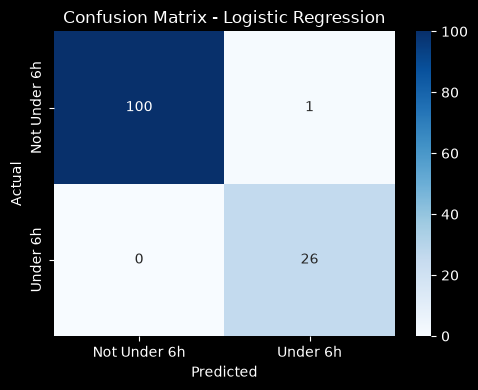

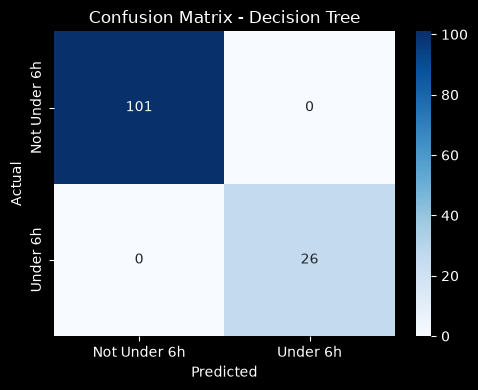

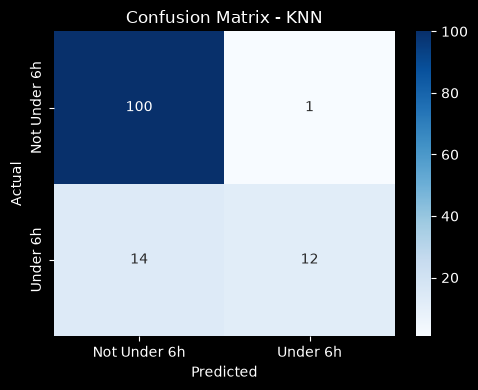

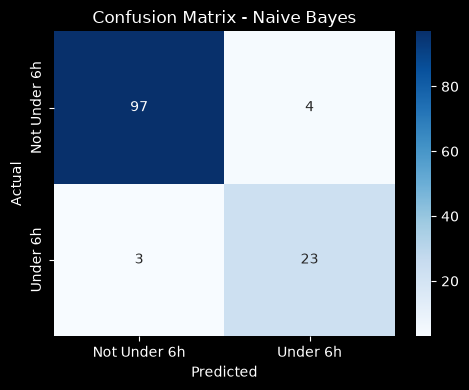

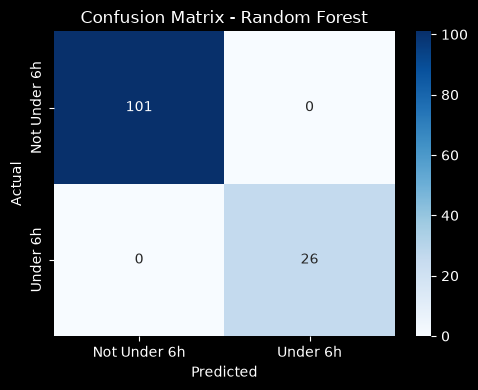

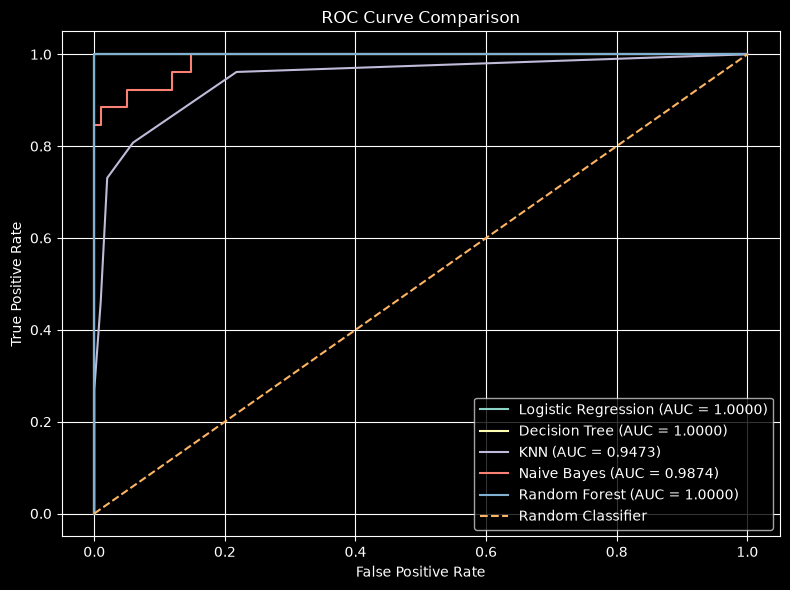


Model comparison saved to:
results/model_comparison.csv

STEP 4 COMPLETED SUCCESSFULLY

Models evaluated:
✓ Logistic Regression
✓ Decision Tree
✓ KNN
✓ Naive Bayes
✓ Random Forest

Metrics calculated:
✓ Accuracy
✓ AUC
✓ Precision
✓ Recall
✓ F1 Score
✓ MCC

Output file:
✓ results/model_comparison.csv


In [27]:
# ============================================================
# STEP 4 - MODEL EVALUATION
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    roc_curve
)


print("=" * 70)
print("STEP 4 - MODEL EVALUATION")
print("=" * 70)


# ------------------------------------------------------------
# 1. Define evaluation metrics
# ------------------------------------------------------------

results = []


# ------------------------------------------------------------
# 2. Evaluate every model
# ------------------------------------------------------------

for model_name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probability of positive class
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    # Store results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "MCC": mcc
    })


# ------------------------------------------------------------
# 3. Create comparison DataFrame
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1 Score",
    "MCC"
]

results_df[metric_columns] = results_df[
    metric_columns
].round(4)


# ------------------------------------------------------------
# 4. Display comparison table
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)

display(results_df)


# ------------------------------------------------------------
# 5. Find best model for each metric
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BEST MODEL FOR EACH METRIC")
print("=" * 70)

for metric in metric_columns:

    best_index = results_df[metric].idxmax()

    best_model = results_df.loc[
        best_index,
        "Model"
    ]

    best_score = results_df.loc[
        best_index,
        metric
    ]

    print(
        f"{metric:<12} → "
        f"{best_model:<22} "
        f"({best_score:.4f})"
    )


# ------------------------------------------------------------
# 6. Calculate average score
# ------------------------------------------------------------

results_df["Average Score"] = (
    results_df[metric_columns].mean(axis=1)
)

results_df["Average Score"] = results_df[
    "Average Score"
].round(4)

results_df = results_df.sort_values(
    by="Average Score",
    ascending=False
)

print("\n" + "=" * 70)
print("MODEL RANKING")
print("=" * 70)

display(results_df)


# ------------------------------------------------------------
# 7. Classification reports
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLASSIFICATION REPORTS")
print("=" * 70)

for model_name, model in models.items():

    y_pred = model.predict(X_test)

    print("\n" + "-" * 70)
    print(model_name)
    print("-" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Not Under 6 Hours",
                "Under 6 Hours"
            ],
            zero_division=0
        )
    )


# ------------------------------------------------------------
# 8. Confusion matrices
# ------------------------------------------------------------

for model_name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Not Under 6h",
            "Under 6h"
        ],
        yticklabels=[
            "Not Under 6h",
            "Under 6h"
        ]
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 9. ROC curve comparison
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for model_name, model in models.items():

    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc:.4f})"
    )


# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Save results
# ------------------------------------------------------------

os.makedirs(
    "results",
    exist_ok=True
)

results_df.to_csv(
    "results/model_comparison.csv",
    index=False
)

print("\nModel comparison saved to:")
print("results/model_comparison.csv")


# ------------------------------------------------------------
# 11. Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 4 COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nModels evaluated:")
for model_name in models:
    print("✓", model_name)

print("\nMetrics calculated:")
for metric in metric_columns:
    print("✓", metric)

print("\nOutput file:")
print("✓ results/model_comparison.csv")

Model Comparison & Observations

STEP 5 - MODEL COMPARISON & OBSERVATIONS

Evaluation results loaded successfully.

MODEL PERFORMANCE COMPARISON


,Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,Logistic Regression,0.9921,1.0000,0.9630,1.0000,0.9811,0.9764
3,Naive Bayes,0.9449,0.9874,0.8519,0.8846,0.8679,0.8334
4,KNN,0.8819,0.9473,0.9231,0.4615,0.6154,0.6012



BEST MODEL FOR EACH METRIC
Accuracy     : Decision Tree          (1.0000)
AUC          : Decision Tree          (1.0000)
Precision    : Decision Tree          (1.0000)
Recall       : Decision Tree          (1.0000)
F1 Score     : Decision Tree          (1.0000)
MCC          : Decision Tree          (1.0000)

MODEL RANKING


,Model,Accuracy Rank,AUC Rank,Precision Rank,Recall Rank,F1 Score Rank,MCC Rank,Mean Rank
0,Decision Tree,1,1,1,1,1,1,1.00
1,Random Forest,1,1,1,1,1,1,1.00
2,Logistic Regression,3,1,3,1,3,3,2.33
3,Naive Bayes,4,4,5,4,4,4,4.17
4,KNN,5,5,4,5,5,5,4.83



OVERALL MODEL
Best overall model based on mean metric score: Decision Tree
Mean score: 1.0000


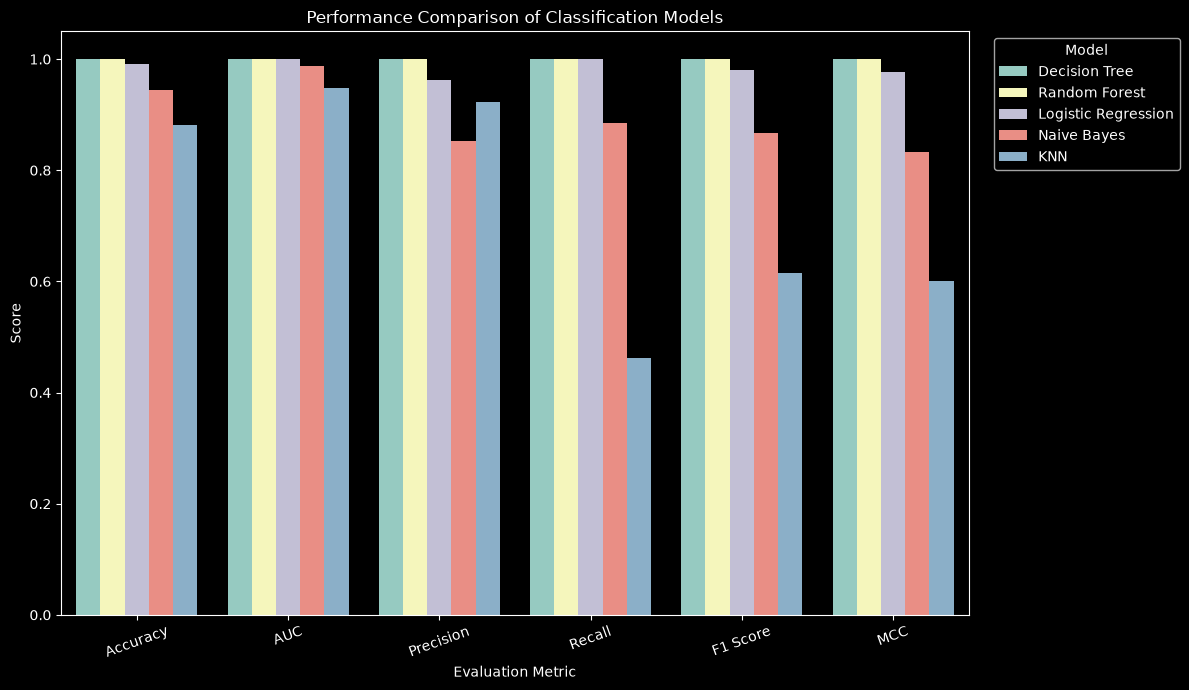

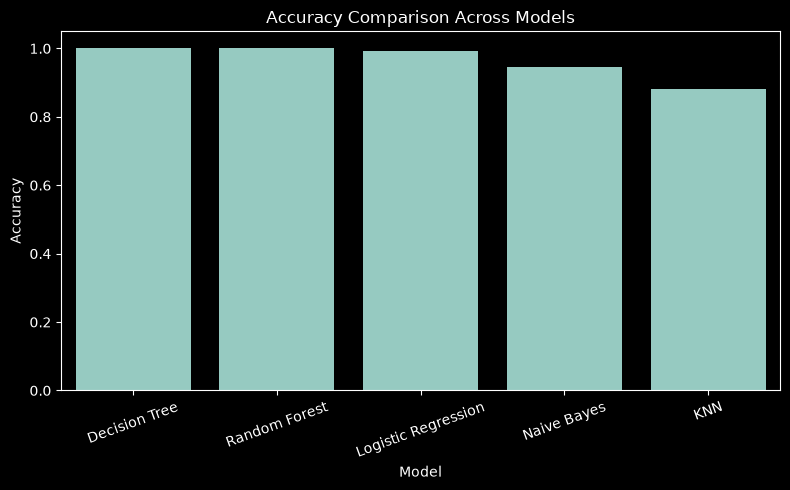

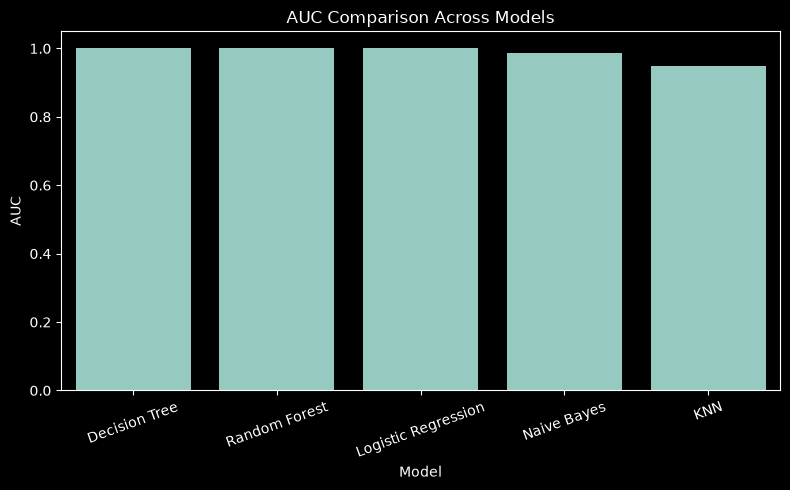

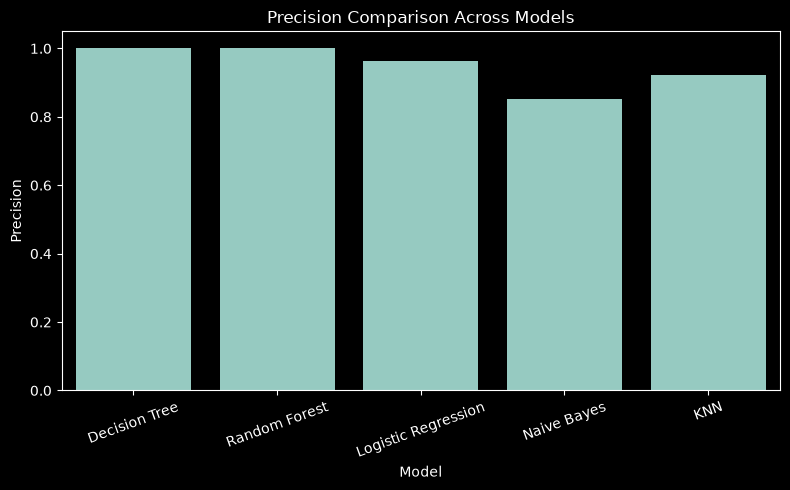

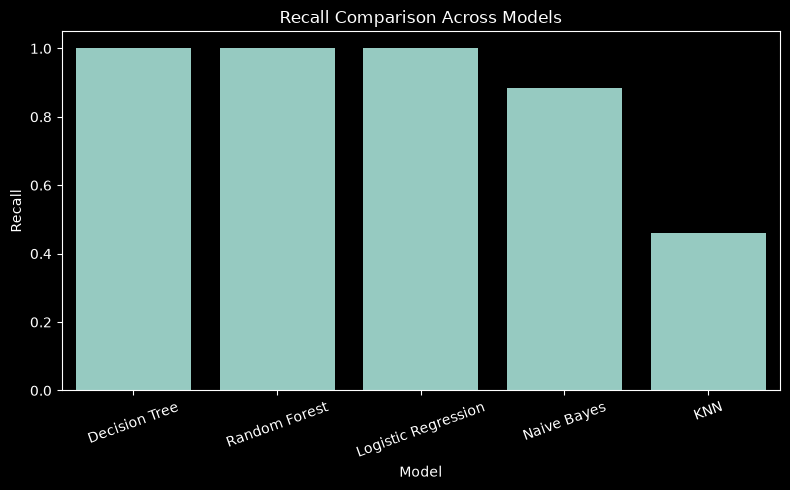

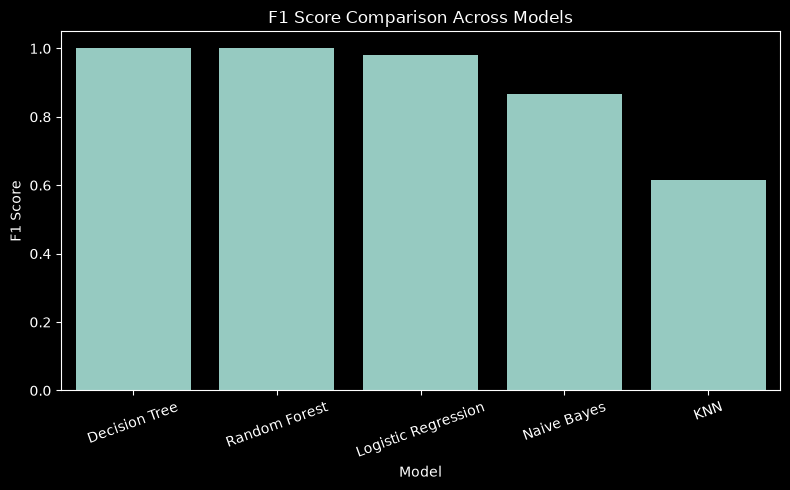

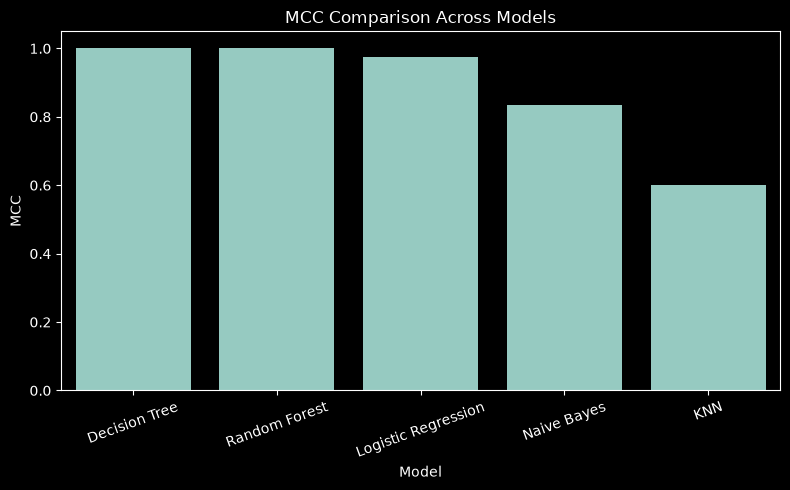


MODEL COMPARISON OBSERVATIONS
• Decision Tree achieved the highest Accuracy with a score of 1.0000.
• Decision Tree achieved the highest AUC with a score of 1.0000.
• Decision Tree achieved the highest Precision with a score of 1.0000.
• Decision Tree achieved the highest Recall with a score of 1.0000.
• Decision Tree achieved the highest F1 Score with a score of 1.0000.
• Decision Tree achieved the highest MCC with a score of 1.0000.

STEP 5 COMPLETED SUCCESSFULLY

Files created:
✓ results/final_model_comparison.csv
✓ results/model_ranking.csv


In [28]:
# ============================================================
# STEP 5 - MODEL COMPARISON & OBSERVATIONS
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


print("=" * 70)
print("STEP 5 - MODEL COMPARISON & OBSERVATIONS")
print("=" * 70)


# ------------------------------------------------------------
# 1. Load evaluation results
# ------------------------------------------------------------

results_df = pd.read_csv(
    "results/model_comparison.csv"
)

print("\nEvaluation results loaded successfully.")


# ------------------------------------------------------------
# 2. Define required metrics
# ------------------------------------------------------------

metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1 Score",
    "MCC"
]


# ------------------------------------------------------------
# 3. Create clean comparison table
# ------------------------------------------------------------

comparison_df = results_df[
    ["Model"] + metric_columns
].copy()

comparison_df[metric_columns] = comparison_df[
    metric_columns
].round(4)

print("\n" + "=" * 70)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)

display(comparison_df)


# ------------------------------------------------------------
# 4. Find best model for each metric
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BEST MODEL FOR EACH METRIC")
print("=" * 70)

best_models = {}

for metric in metric_columns:

    best_index = comparison_df[metric].idxmax()

    best_model = comparison_df.loc[
        best_index,
        "Model"
    ]

    best_score = comparison_df.loc[
        best_index,
        metric
    ]

    best_models[metric] = best_model

    print(
        f"{metric:<12} : "
        f"{best_model:<22} "
        f"({best_score:.4f})"
    )


# ------------------------------------------------------------
# 5. Rank models
# ------------------------------------------------------------

ranking_df = comparison_df.copy()

for metric in metric_columns:

    ranking_df[f"{metric} Rank"] = (
        ranking_df[metric]
        .rank(
            ascending=False,
            method="min"
        )
        .astype(int)
    )


# ------------------------------------------------------------
# 6. Calculate mean rank
# ------------------------------------------------------------

rank_columns = [
    f"{metric} Rank"
    for metric in metric_columns
]

ranking_df["Mean Rank"] = ranking_df[
    rank_columns
].mean(axis=1)

ranking_df["Mean Rank"] = ranking_df[
    "Mean Rank"
].round(2)

ranking_df = ranking_df.sort_values(
    by="Mean Rank"
)

print("\n" + "=" * 70)
print("MODEL RANKING")
print("=" * 70)

display(
    ranking_df[
        ["Model"] + rank_columns + ["Mean Rank"]
    ]
)


# ------------------------------------------------------------
# 7. Calculate overall mean score
# ------------------------------------------------------------

comparison_df["Overall Mean"] = comparison_df[
    metric_columns
].mean(axis=1)

comparison_df["Overall Mean"] = comparison_df[
    "Overall Mean"
].round(4)

best_overall_index = comparison_df[
    "Overall Mean"
].idxmax()

best_overall_model = comparison_df.loc[
    best_overall_index,
    "Model"
]

best_overall_score = comparison_df.loc[
    best_overall_index,
    "Overall Mean"
]

print("\n" + "=" * 70)
print("OVERALL MODEL")
print("=" * 70)

print(
    f"Best overall model based on mean metric score: "
    f"{best_overall_model}"
)

print(
    f"Mean score: {best_overall_score:.4f}"
)


# ------------------------------------------------------------
# 8. Combined comparison chart
# ------------------------------------------------------------

comparison_plot_df = comparison_df.melt(
    id_vars="Model",
    value_vars=metric_columns,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=comparison_plot_df,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title(
    "Performance Comparison of Classification Models"
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.xticks(rotation=20)

plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Individual metric charts
# ------------------------------------------------------------

for metric in metric_columns:

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=comparison_df,
        x="Model",
        y=metric
    )

    plt.title(
        f"{metric} Comparison Across Models"
    )

    plt.xlabel("Model")
    plt.ylabel(metric)

    plt.xticks(rotation=20)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 10. Generate observations
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MODEL COMPARISON OBSERVATIONS")
print("=" * 70)

for metric in metric_columns:

    best_index = comparison_df[metric].idxmax()

    model = comparison_df.loc[
        best_index,
        "Model"
    ]

    score = comparison_df.loc[
        best_index,
        metric
    ]

    print(
        f"• {model} achieved the highest "
        f"{metric} with a score of {score:.4f}."
    )


# ------------------------------------------------------------
# 11. Save final comparison
# ------------------------------------------------------------

os.makedirs(
    "results",
    exist_ok=True
)

comparison_df.to_csv(
    "results/final_model_comparison.csv",
    index=False
)

ranking_df[
    ["Model"] + rank_columns + ["Mean Rank"]
].to_csv(
    "results/model_ranking.csv",
    index=False
)


# ------------------------------------------------------------
# 12. Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 5 COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nFiles created:")

print(
    "✓ results/final_model_comparison.csv"
)

print(
    "✓ results/model_ranking.csv"
)

In [29]:
# ============================================================
# STEP 3 - PART 1
# Create test_data.csv from the original dataset
# ============================================================

import os
import pandas as pd
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. Original dataset path
# ------------------------------------------------------------

DATA_PATH = r"C:\Users\10689473\Downloads\college_sleep_and_gpa.csv"


# ------------------------------------------------------------
# 2. Load the original dataset
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH)

print("Original dataset loaded successfully.")
print("Original dataset shape:", df.shape)


# ------------------------------------------------------------
# 3. Check that the target column exists
# ------------------------------------------------------------

TARGET = "under_6h_sleep"

if TARGET not in df.columns:
    raise ValueError(
        f"Target column '{TARGET}' was not found in the dataset."
    )


# ------------------------------------------------------------
# 4. Create training and test datasets
# ------------------------------------------------------------

train_data, test_data = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df[TARGET]
)


# ------------------------------------------------------------
# 5. Save the test dataset
# ------------------------------------------------------------

TEST_FILE = "test_data.csv"

test_data.to_csv(
    TEST_FILE,
    index=False
)


# ------------------------------------------------------------
# 6. Display results
# ------------------------------------------------------------

print("\nTest data created successfully!")
print("Training data shape:", train_data.shape)
print("Test data shape:", test_data.shape)
print("Test file location:", os.path.abspath(TEST_FILE))


# ------------------------------------------------------------
# 7. Display first five rows
# ------------------------------------------------------------

print("\nFirst 5 rows of test_data.csv:")

display(test_data.head())

Original dataset loaded successfully.
Original dataset shape: (634, 22)

Test data created successfully!
Training data shape: (507, 22)
Test data shape: (127, 22)
Test file location: C:\Users\10689473\PycharmProjects\JupyterProject\test_data.csv

First 5 rows of test_data.csv:


,student_id,study,university,semester,cohort_code,gender,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,...,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep,sleep_bracket,sleep_midpoint_clock
327,517,3,University of Washington,Spring 2019,uw2,Female,1.0,0.0,511.8,8.53,...,0.0233,0.893,3.240,2.800,-0.440,13.0,-1.000,0,7.5h+,05:32
170,141,2,University of Washington,Spring 2018,uw1,Female,0.0,0.0,451.8,7.53,...,0.1430,0.893,3.333,2.533,-0.800,15.0,0.373,0,7.5h+,04:16
422,47810,4,University of Notre Dame,Spring 2016,nh,Female,0.0,0.0,437.3,7.29,...,0.0465,0.900,3.619,3.611,-0.008,NaN,NaN,0,7-7.5h,05:07
576,241,5,Carnegie Mellon University,Spring 2017,lac1,Female,0.0,0.0,393.5,6.56,...,0.2428,0.793,3.810,3.600,-0.210,49.0,-0.139,0,6.5-7h,05:16
227,325,3,University of Washington,Spring 2019,uw2,Female,1.0,0.0,353.3,5.89,...,0.1567,1.000,3.011,3.390,0.379,16.0,0.562,1,5.5-6h,05:54


In [32]:
# ============================================================
# STEP 3 - PART 2
# SAVE THE FIVE TRAINED MODELS
# ============================================================

import os
import joblib

# ------------------------------------------------------------
# 1. Create the model folder
# ------------------------------------------------------------

MODEL_FOLDER = r"C:\Users\10689473\PycharmProjects\JupyterProject\model"

os.makedirs(MODEL_FOLDER, exist_ok=True)


# ------------------------------------------------------------
# 2. Display the models already available
# ------------------------------------------------------------

print("Models available in the notebook:")
print()

for model_name in models.keys():
    print("✓", model_name)


# ------------------------------------------------------------
# 3. Save each trained model
# ------------------------------------------------------------

saved_files = []

for model_name, model in models.items():

    # Convert model name into a suitable filename
    filename = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    file_path = os.path.join(
        MODEL_FOLDER,
        filename + ".pkl"
    )

    # Save the trained model
    joblib.dump(model, file_path)

    saved_files.append(file_path)

    print(f"\n✓ Saved: {model_name}")
    print(f"  File: {file_path}")


# ------------------------------------------------------------
# 4. Save the preprocessor
# ------------------------------------------------------------

preprocessor_path = os.path.join(
    MODEL_FOLDER,
    "preprocessor.pkl"
)

joblib.dump(
    preprocessor,
    preprocessor_path
)

print("\n✓ Saved: Preprocessor")
print(f"  File: {preprocessor_path}")


# ------------------------------------------------------------
# 5. Verify all saved files
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MODEL FOLDER VERIFICATION")
print("=" * 60)

for file_name in sorted(os.listdir(MODEL_FOLDER)):

    file_path = os.path.join(
        MODEL_FOLDER,
        file_name
    )

    if os.path.isfile(file_path):

        size_kb = os.path.getsize(file_path) / 1024

        print(
            f"✓ {file_name:<30} "
            f"{size_kb:.2f} KB"
        )


# ------------------------------------------------------------
# 6. Final message
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STEP 3 - PART 2 COMPLETED")
print("=" * 60)

print("\nSaved model files are located in:")
print(MODEL_FOLDER)

Models available in the notebook:

✓ Logistic Regression
✓ Decision Tree
✓ KNN
✓ Naive Bayes
✓ Random Forest

✓ Saved: Logistic Regression
  File: C:\Users\10689473\PycharmProjects\JupyterProject\model\logistic_regression.pkl

✓ Saved: Decision Tree
  File: C:\Users\10689473\PycharmProjects\JupyterProject\model\decision_tree.pkl

✓ Saved: KNN
  File: C:\Users\10689473\PycharmProjects\JupyterProject\model\knn.pkl

✓ Saved: Naive Bayes
  File: C:\Users\10689473\PycharmProjects\JupyterProject\model\naive_bayes.pkl

✓ Saved: Random Forest
  File: C:\Users\10689473\PycharmProjects\JupyterProject\model\random_forest.pkl

✓ Saved: Preprocessor
  File: C:\Users\10689473\PycharmProjects\JupyterProject\model\preprocessor.pkl

MODEL FOLDER VERIFICATION
✓ decision_tree.pkl              6.50 KB
✓ knn.pkl                        120.66 KB
✓ logistic_regression.pkl        6.06 KB
✓ naive_bayes.pkl                6.61 KB
✓ preprocessor.pkl               5.17 KB
✓ random_forest.pkl              511.82 K

In [3]:
# ============================================================
# STEP 5 - REBUILD DATA, TRAIN 5 MODELS, AND GET METRICS
# ============================================================

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

# ============================================================
# 1. LOAD YOUR DATASET
# ============================================================

DATA_PATH = r"C:\Users\10689473\Downloads\college_sleep_and_gpa.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)


# ============================================================
# 2. DEFINE TARGET
# ============================================================

TARGET = "under_6h_sleep"

if TARGET not in df.columns:
    raise ValueError(
        f"Target column '{TARGET}' was not found.\n"
        f"Available columns are:\n{df.columns.tolist()}"
    )

print("\nTarget column:", TARGET)


# ============================================================
# 3. REMOVE MISSING TARGET VALUES
# ============================================================

df = df.dropna(subset=[TARGET]).copy()

print("Shape after removing missing target values:", df.shape)


# ============================================================
# 4. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop(columns=[TARGET])
y = df[TARGET]


# ============================================================
# 5. REMOVE ID-LIKE COLUMNS IF PRESENT
# ============================================================

# These columns are identifiers rather than useful predictive
# features. Only remove them if they actually exist.

possible_id_columns = [
    "id",
    "ID",
    "student_id",
    "studentid",
    "Student_ID"
]

columns_to_remove = [
    col for col in possible_id_columns
    if col in X.columns
]

if columns_to_remove:

    X = X.drop(columns=columns_to_remove)

    print(
        "\nRemoved identifier columns:",
        columns_to_remove
    )

else:

    print("\nNo identifier columns found.")


# ============================================================
# 6. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


# ============================================================
# 7. CREATE PREPROCESSOR
# ============================================================

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# ============================================================
# 8. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


# ============================================================
# 9. DEFINE FIVE REQUIRED MODELS
# ============================================================

model_definitions = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}


# ============================================================
# 10. TRAIN AND EVALUATE MODELS
# ============================================================

results_list = []
trained_models = {}

for model_name, model in model_definitions.items():

    print("\n" + "-" * 60)
    print("Training:", model_name)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Prediction
    y_pred = pipeline.predict(X_test)

    # Probability for AUC
    if hasattr(pipeline, "predict_proba"):

        y_prob = pipeline.predict_proba(X_test)[:, 1]

        auc = roc_auc_score(
            y_test,
            y_prob
        )

    else:

        auc = np.nan

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    results_list.append({
        "ML Model Name": model_name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "MCC": mcc
    })

    trained_models[model_name] = pipeline

    print("✓ Completed")


# ============================================================
# 11. CREATE RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results_list)

print("\n")
print("=" * 90)
print("MODEL COMPARISON RESULTS")
print("=" * 90)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "AUC": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "MCC": "{:.4f}"
    })
)


# ============================================================
# 12. FIND OVERALL WINNER
# ============================================================

winner_index = results_df["F1"].idxmax()

winner = results_df.loc[winner_index]

print("\n")
print("=" * 90)
print("OVERALL WINNER")
print("=" * 90)

print("Model    :", winner["ML Model Name"])
print("Accuracy :", f"{winner['Accuracy']:.4f}")
print("AUC      :", f"{winner['AUC']:.4f}")
print("Precision:", f"{winner['Precision']:.4f}")
print("Recall   :", f"{winner['Recall']:.4f}")
print("F1       :", f"{winner['F1']:.4f}")
print("MCC      :", f"{winner['MCC']:.4f}")


# ============================================================
# 13. SAVE THE RESULTS
# ============================================================

RESULTS_FILE = os.path.join(
    os.getcwd(),
    "model_comparison_results.csv"
)

results_df.to_csv(
    RESULTS_FILE,
    index=False
)

print("\n✓ Results saved to:")
print(RESULTS_FILE)


# ============================================================
# 14. SAVE THE TRAINED MODELS
# ============================================================

import joblib

MODEL_FOLDER = r"C:\Users\10689473\PycharmProjects\JupyterProject\model"

os.makedirs(
    MODEL_FOLDER,
    exist_ok=True
)

model_filenames = {
    "Logistic Regression": "logistic_regression.pkl",
    "Decision Tree": "decision_tree.pkl",
    "KNN": "knn.pkl",
    "Naive Bayes": "naive_bayes.pkl",
    "Random Forest": "random_forest.pkl"
}

for model_name, pipeline in trained_models.items():

    filename = model_filenames[model_name]

    filepath = os.path.join(
        MODEL_FOLDER,
        filename
    )

    joblib.dump(
        pipeline,
        filepath
    )

    print("✓ Saved:", filepath)


print("\n" + "=" * 90)
print("STEP 5 MODEL PREPARATION COMPLETED")
print("=" * 90)

Dataset loaded successfully.
Dataset shape: (634, 22)

Target column: under_6h_sleep
Shape after removing missing target values: (634, 22)

Removed identifier columns: ['student_id']

Numerical features:
['study', 'first_generation', 'underrepresented', 'avg_sleep_minutes', 'avg_sleep_hours', 'daytime_sleep_minutes', 'sleep_midpoint_minutes', 'bedtime_variability', 'nights_tracked_fraction', 'prior_gpa', 'term_gpa', 'gpa_change', 'term_units', 'term_load_z']

Categorical features:
['university', 'semester', 'cohort_code', 'gender', 'sleep_bracket', 'sleep_midpoint_clock']

Training data shape: (507, 20)
Testing data shape: (127, 20)

------------------------------------------------------------
Training: Logistic Regression
✓ Completed

------------------------------------------------------------
Training: Decision Tree


C:\Users\10689473\AppData\Local\Temp\ipykernel_11052\1394624497.py:116: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


✓ Completed

------------------------------------------------------------
Training: KNN
✓ Completed

------------------------------------------------------------
Training: Naive Bayes
✓ Completed

------------------------------------------------------------
Training: Random Forest
✓ Completed


MODEL COMPARISON RESULTS


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,KNN,0.9370,0.9966,1.0000,0.6923,0.8182,0.8009
3,Naive Bayes,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000




OVERALL WINNER
Model    : Logistic Regression
Accuracy : 1.0000
AUC      : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1       : 1.0000
MCC      : 1.0000

✓ Results saved to:
C:\Users\10689473\PycharmProjects\JupyterProject\model_comparison_results.csv
✓ Saved: C:\Users\10689473\PycharmProjects\JupyterProject\model\logistic_regression.pkl
✓ Saved: C:\Users\10689473\PycharmProjects\JupyterProject\model\decision_tree.pkl
✓ Saved: C:\Users\10689473\PycharmProjects\JupyterProject\model\knn.pkl
✓ Saved: C:\Users\10689473\PycharmProjects\JupyterProject\model\naive_bayes.pkl
✓ Saved: C:\Users\10689473\PycharmProjects\JupyterProject\model\random_forest.pkl

STEP 5 MODEL PREPARATION COMPLETED


In [4]:
# ============================================================
# DISPLAY THE MODEL RESULTS
# ============================================================

print("=" * 90)
print("MODEL COMPARISON RESULTS")
print("=" * 90)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "AUC": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "MCC": "{:.4f}"
    })
)

# Find the best model using F1 score
winner_index = results_df["F1"].idxmax()
winner = results_df.loc[winner_index]

print("\n" + "=" * 90)
print("OVERALL WINNER")
print("=" * 90)

print("Model    :", winner["ML Model Name"])
print("Accuracy :", f"{winner['Accuracy']:.4f}")
print("AUC      :", f"{winner['AUC']:.4f}")
print("Precision:", f"{winner['Precision']:.4f}")
print("Recall   :", f"{winner['Recall']:.4f}")
print("F1       :", f"{winner['F1']:.4f}")
print("MCC      :", f"{winner['MCC']:.4f}")

MODEL COMPARISON RESULTS


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,KNN,0.9370,0.9966,1.0000,0.6923,0.8182,0.8009
3,Naive Bayes,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000



OVERALL WINNER
Model    : Logistic Regression
Accuracy : 1.0000
AUC      : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1       : 1.0000
MCC      : 1.0000
